# Multiple Linear Regression - Quick Revision Notes

**Goal:** predict one number using **more than one input**.

Example: predict a house price from its size, number of rooms, and location.

## 1. Simple vs Multiple

| Type | Number of inputs | Example |
|---|---:|---|
| **Simple Linear Regression** | 1 | Predict height from weight. |
| **Multiple Linear Regression** | 2 or more | Predict house price from size, rooms, and location. |

Think of it like this: simple regression listens to **one clue**. Multiple regression listens to **many clues** before making its answer.

## 2. House-price example

| Input feature (clue) | Meaning | Output |
|---|---|---|
| $x_1$ | number of rooms | |
| $x_2$ | size of the house | **price** $y$ |
| $x_3$ | location | |

- **Features / inputs** are the clues we give the model.
- **Target / output** is the answer we want to predict.
- Words such as location must first be changed into numbers (for example, using one-hot encoding).

## 3. The prediction formula

$$\hat{y} = \theta_0 + \theta_1x_1 + \theta_2x_2 + \theta_3x_3$$

Read it in easy English:

**predicted price = starting value + rooms effect + size effect + location effect**

- $\hat{y}$: the model's predicted answer.
- $\theta_0$: the **intercept** (the starting value). There is always **one** intercept.
- $\theta_1, \theta_2, \theta_3$: **coefficients** (also called slopes or weights). Each feature gets one coefficient.
- $x_1, x_2, x_3$: input feature values.

**Rule to remember:** if there are $n$ input features, there are $n$ coefficients plus one intercept.

## 4. Tiny number example

Suppose a simple model learns:

$$\text{price (lakhs)} = 20 + 5(\text{rooms}) + 0.02(\text{size in sq ft})$$

For a house with 2 rooms and 1,000 sq ft:

$$20 + 5(2) + 0.02(1000) = 20 + 10 + 20 = 50$$

The predicted price is **50 lakhs**. Each part adds its own small contribution.

## 5. How does it learn?

1. Start with guessed values for $\theta_0, \theta_1, \theta_2, \ldots$.
2. Make predictions for the training houses.
3. Measure how wrong the predictions are with a **cost** (usually Mean Squared Error).
4. Use **Gradient Descent** to gently change *all* coefficients so the cost becomes smaller.
5. Stop when the changes become very small: the model has found a good fit.

In simple English, Gradient Descent is like walking downhill in fog: take small steps in the direction that reduces mistakes.

## Visual diagram: many clues, one prediction

Run the next cell. The left picture shows the information flow. The right picture shows a flat prediction surface (a plane) fitted through houses using two numeric features. With one feature, the fit looks like a line; with two features, it looks like a plane.

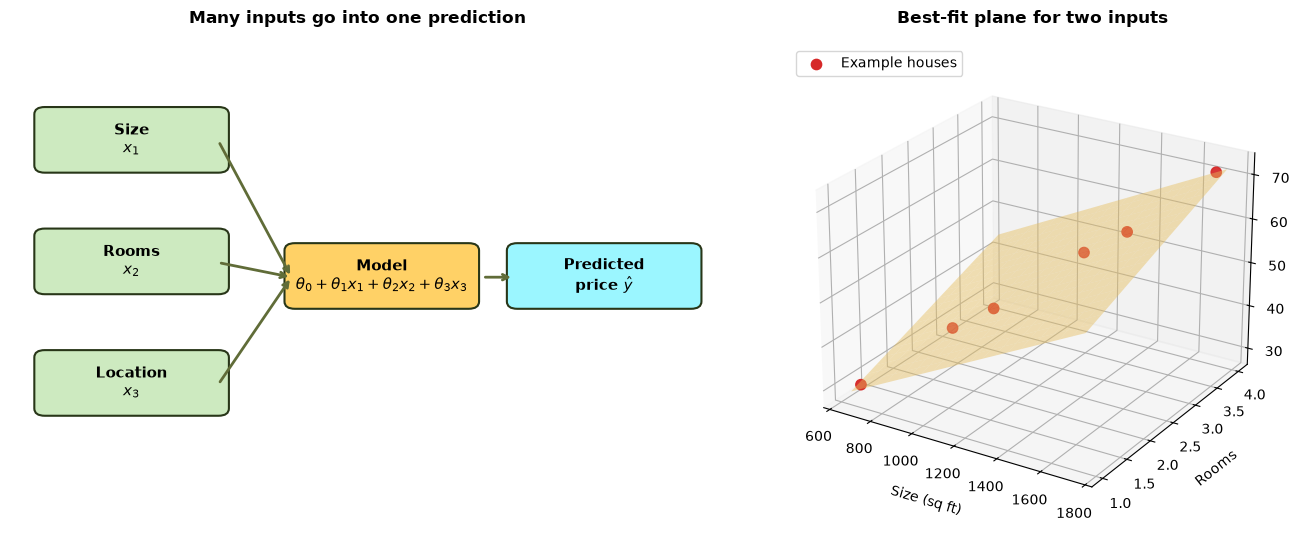

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Toy house data: size (sq ft), rooms, and price (lakhs)
size = np.array([700, 900, 1100, 1300, 1500, 1700])
rooms = np.array([1, 2, 2, 3, 3, 4])
price = 8 + 0.025 * size + 5 * rooms + np.array([1, -1, 1, -1, 1, 0])

fig = plt.figure(figsize=(14, 5.5))

# Left: explain the flow from features to one predicted price
ax1 = fig.add_subplot(121)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')

def box(ax, x, y, text, color):
    patch = FancyBboxPatch((x, y), 2.5, 1.05, boxstyle='round,pad=0.15',
                           facecolor=color, edgecolor='#283618', linewidth=1.5)
    ax.add_patch(patch)
    ax.text(x + 1.25, y + 0.53, text, ha='center', va='center', fontsize=11, weight='bold')

box(ax1, 0.5, 7.5, 'Size\n$x_1$', '#cdeac0')
box(ax1, 0.5, 5.0, 'Rooms\n$x_2$', '#cdeac0')
box(ax1, 0.5, 2.5, 'Location\n$x_3$', '#cdeac0')
box(ax1, 4.1, 4.7, 'Model\n$\\theta_0 + \\theta_1x_1 + \\theta_2x_2 + \\theta_3x_3$', '#ffd166')
box(ax1, 7.3, 4.7, 'Predicted\nprice $\\hat{y}$', '#9bf6ff')

for y in [8.0, 5.5, 3.0]:
    ax1.annotate('', xy=(4.05, 5.2), xytext=(3.0, y),
                 arrowprops=dict(arrowstyle='->', lw=2, color='#606c38'))
ax1.annotate('', xy=(7.25, 5.2), xytext=(6.8, 5.2),
             arrowprops=dict(arrowstyle='->', lw=2, color='#606c38'))
ax1.set_title('Many inputs go into one prediction', weight='bold', pad=15)

# Right: a plane is the multiple-regression version of a best-fit line
ax2 = fig.add_subplot(122, projection='3d')
size_grid, rooms_grid = np.meshgrid(np.linspace(650, 1750, 20), np.linspace(1, 4, 20))
price_plane = 8 + 0.025 * size_grid + 5 * rooms_grid
ax2.plot_surface(size_grid, rooms_grid, price_plane, color='#ffd166', alpha=0.45, edgecolor='none')
ax2.scatter(size, rooms, price, color='#d62828', s=55, label='Example houses')
ax2.set_xlabel('Size (sq ft)', labelpad=8)
ax2.set_ylabel('Rooms', labelpad=8)
ax2.set_zlabel('Price (lakhs)', labelpad=8)
ax2.set_title('Best-fit plane for two inputs', weight='bold', pad=15)
ax2.legend(loc='upper left')
ax2.view_init(elev=24, azim=-58)

plt.tight_layout()
plt.show()


## 6. Exam-ready recap

- **Simple** linear regression: one input feature.
- **Multiple** linear regression: more than one input feature.
- Formula: $\hat{y} = \theta_0 + \theta_1x_1 + \cdots + \theta_nx_n$.
- $\theta_0$ is the one intercept; every feature gets its own coefficient.
- Gradient Descent updates the intercept and every coefficient to reduce prediction errors.

**One-line answer:** Multiple Linear Regression predicts a numeric output by combining the effects of two or more input features.